## EDS extraction

In [2]:
## hibaüzenet, ha nincs multicomponentdata.xml az eds-ben
import zipfile
import xml.etree.ElementTree as ET
import io
import pandas as pd

def eds_extract_with_no_platesetup(file):
    xml_path = "apldbio/sds/multicomponentdata.xml"
    rows = []

    try:
        with zipfile.ZipFile(file, 'r') as z:
            try:
                xml_data = z.read(xml_path)
            except KeyError:
                raise FileNotFoundError(
                    f"Hiba: az EDS fájl nem tartalmazza a szükséges XML-t: {xml_path}"
                )

    except zipfile.BadZipFile:
        raise ValueError("Hiba: a megadott fájl nem érvényes EDS (nem ZIP formátum).")

    # XML feldolgozás
    try:
        root = ET.parse(io.BytesIO(xml_data)).getroot()
    except ET.ParseError:
        raise ValueError("Hiba: a multicomponentdata.xml nem érvényes XML.")

    dye_map = {}

    for dye_data in root.iter("DyeData"):
        well_index = int(dye_data.attrib.get("WellIndex", -1))
        dye_list_elem = dye_data.find("DyeList")
        if dye_list_elem is None:
            continue

        dyes = [d.strip() for d in dye_list_elem.text.strip("[]").split(",")]
        if len(dyes) > 2:
            dye_map[well_index] = dyes

    for signal_data in root.iter("SignalData"):
        well_index = int(signal_data.attrib.get("WellIndex", -1))
        dyes = dye_map.get(well_index)

        if dyes is None:
            continue

        cycle_data_elements = signal_data.findall("CycleData")

        for dye_idx, cycle_data in enumerate(cycle_data_elements):
            if dye_idx >= len(dyes):
                continue

            dye = dyes[dye_idx]
            values = [float(v) for v in cycle_data.text.strip("[]").split(",")]

            for cycle_idx, value in enumerate(values):
                rows.append({
                    "well": well_index + 1,
                    "cycle": cycle_idx + 1,
                    "dye": dye,
                    "data": value
                })

    if not rows:
        raise ValueError("Hiba: nem sikerült multicomponent adatot kinyerni az EDS-ből.")
    
    raw_data = pd.DataFrame(rows)
    
    #well position hozzáadása
    row = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']
    column = list(range(1,25))
    well_pos = {}
    a = 1
    for j in row:
        for i in range(1,25): 
            well_pos[a] = j+str(i)
            a = a+1

    raw_data['well_position'] = raw_data['well'].map(well_pos)
    
    #pivot dataframe
    pivot_raw_data = raw_data.pivot(index=('well','well_position','cycle',), columns='dye', values='data')
    pivot_raw_data = pivot_raw_data.reset_index()
    
    #count dyes mean and omit wells where mean under 8000
    cols_after_cycle = pivot_raw_data.columns[pivot_raw_data.columns.get_loc('cycle') + 1:]
    pivot_raw_data['atlag'] = pivot_raw_data[cols_after_cycle].mean(axis=1)
    
    pivot_raw_data_omit = pivot_raw_data[pivot_raw_data['atlag'] > 8000]

    return pivot_raw_data_omit

raw_data = eds_extract_with_no_platesetup("C:\\Users\\anett\\Documents\\Szakdolgozat_python\\2024-10-17 plazmid_ell.eds")
raw_data

dye,well,well_position,cycle,ABY,CY5,FAM,ROX,VIC,atlag
0,1,A1,1,137867.980,23174.467,275620.280,111554.210,75216.140,124686.6154
1,1,A1,2,136995.160,23135.637,273880.340,110713.320,74561.460,123857.1834
2,1,A1,3,134702.640,22811.050,270512.750,109367.060,73486.240,122175.9480
3,1,A1,4,133481.330,22172.266,267370.940,107097.390,72136.880,120451.7612
4,1,A1,5,131608.550,21621.908,263588.940,105168.790,71256.060,118648.8496
...,...,...,...,...,...,...,...,...,...
16465,366,P6,41,49222.715,13942.023,36763.773,71429.164,98781.990,54027.9330
16466,366,P6,42,49095.670,13925.989,36833.902,71526.870,98888.586,54054.2034
16467,366,P6,43,48919.426,13939.601,36828.754,71694.920,99133.690,54103.2782
16468,366,P6,44,49088.137,14129.888,36726.465,71659.240,99233.980,54167.5420


## PCR görbe vizualizáció

In [27]:
import pandas as pd
import plotly.express as px

a1 = raw_data[raw_data["well_position"] == 'A1']

# df tartalmazza: Cycle, FAM, VIC, CY5, ABY
# a1["Cycle"] = pd.to_numeric(a1["Cycle"], errors="coerce")

# Csatornákat listába tesszük
channels = ["FAM", "VIC", "CY5", "ABY"]

fig = px.line(a1, x="cycle", y=channels, markers=True, title="A1 well")

fig.show()

## PCR görbe simítás

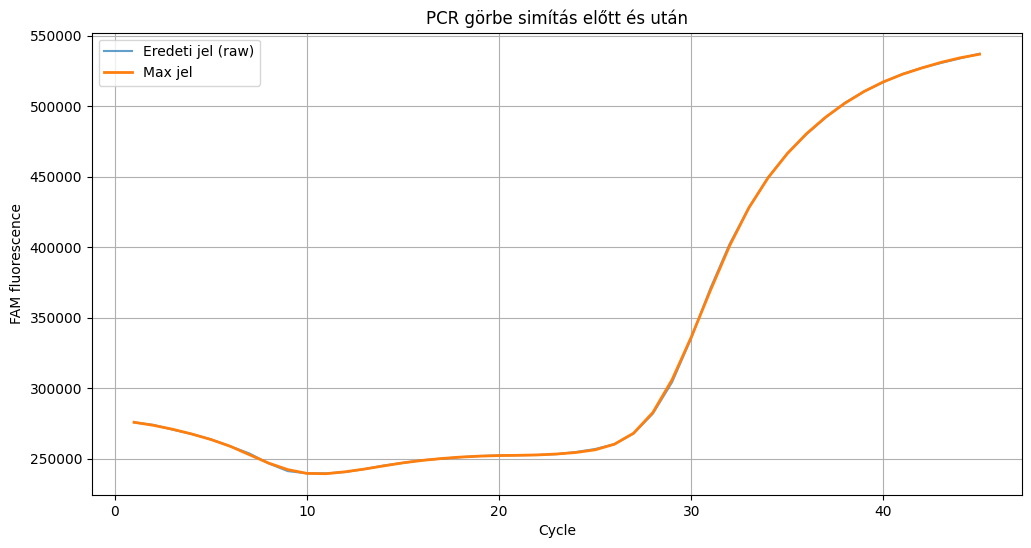

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# -------------------------------------------------------
# 1. SAVITZKY–GOLAY SZŰRÉS
# -------------------------------------------------------

# Ablakméret (mindig legyen páratlan!), polyorder = 2 általában jó)
y_raw = a1["FAM"].values
y_smooth = savgol_filter(y_raw, window_length=7, polyorder=2)

# -------------------------------------------------------
# 2. ÁBRÁZOLÁS
# -------------------------------------------------------

plt.figure(figsize=(12,6))

# Eredeti jel
plt.plot(a1["cycle"], y_raw, label="Eredeti jel (raw)", alpha=0.7)

# Simított jel
plt.plot(a1["cycle"], y_smooth, label="Max jel", linewidth=2)

plt.xlabel("Cycle")
plt.ylabel("FAM fluorescence")
plt.title("PCR görbe simítás előtt és után")
plt.legend()
plt.grid(True)
plt.show()